Install & Imports the libraries

In [ ]:
!pip install wfdb neurokit2 imbalanced-learn

import numpy as np
import wfdb
import neurokit2 as nk
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE

import seaborn as sns

Download MIT-BIH

In [ ]:
data_path = "mitdb/"

wfdb.dl_database("mitdb", data_path)

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

DS1 / DS2 Split (Train and Test)

In [ ]:

DS1 = [
    "100","101","102","103","104","105","106","107",
    "108","109","111","112","113","114","115","116",
    "117","118","119","121","122","123","124"
]

DS2 = [
    "200","201","202","203","205","207","208","209",
    "210","212","213","214","215","217","219","220",
    "221","222","223","228","230","231","232","233","234"
]


AAMI EC57 Mapping

In [ ]:
AAMI_MAP = {

    # N class
    'N': 'N',
    'L': 'N',
    'R': 'N',
    'e': 'N',
    'j': 'N',

    # S class
    'A': 'S',
    'a': 'S',
    'J': 'S',
    'S': 'S',

    # V class
    'V': 'V',
    'E': 'V'
}

Build Dataset Function

In [ ]:
def build_dataset(record_list):

    X = []
    y = []

    for record_name in record_list:

        print(f"Processing record: {record_name}")

        # Load ECG record
        record = wfdb.rdsamp(data_path + record_name)

        ecg_signal = record[0][:, 0]
        fs = record[1]['fs']

        # ECG cleaning + R peak detection
        signals, info = nk.ecg_process(
            ecg_signal,
            sampling_rate=fs
        )

        cleaned = signals["ECG_Clean"]
        rpeaks = info["ECG_R_Peaks"]

        # Load annotations
        annotation = wfdb.rdann(
            data_path + record_name,
            'atr'
        )

        ann_samples = annotation.sample
        ann_symbols = annotation.symbol

        # Beat window size
        window_size = int(0.4 * fs)
        half_window = window_size // 2

        prev_r = None

        for r in rpeaks:

            start = r - half_window
            end = r + half_window

            # Skip boundary beats
            if start <= 0 or end >= len(cleaned):
                continue

            # Find nearest annotation
            idx = np.argmin(np.abs(ann_samples - r))

            # Ensure close enough
            if abs(ann_samples[idx] - r) > 50:
                continue

            symbol = ann_symbols[idx]

            # Ignore beats not in AAMI mapping
            if symbol not in AAMI_MAP:
                continue

            label = AAMI_MAP[symbol]

            # Extract beat segment
            beat = cleaned[start:end]

            # Normalize beat
            beat = (
                beat - np.mean(beat)
            ) / (
                np.std(beat) + 1e-8
            )

            # RR interval
            rr = (
                (r - prev_r) / fs
                if prev_r is not None
                else 0
            )

            prev_r = r

            # Amplitude feature
            amplitude = np.max(beat) - np.min(beat)

            # Energy feature
            energy = np.sum(beat ** 2)

            # Combine features
            beat_features = np.concatenate([
                beat,
                [rr, amplitude, energy]
            ])

            X.append(beat_features)
            y.append(label)

    return np.array(X), np.array(y)


Create Datasets

In [ ]:
X_train, y_train = build_dataset(DS1)

X_test, y_test = build_dataset(DS2)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

Processing record: 100
Processing record: 101
Processing record: 102
Processing record: 103
Processing record: 104
Processing record: 105
Processing record: 106
Processing record: 107
Processing record: 108
Processing record: 109
Processing record: 111
Processing record: 112
Processing record: 113
Processing record: 114
Processing record: 115
Processing record: 116
Processing record: 117
Processing record: 118
Processing record: 119
Processing record: 121
Processing record: 122
Processing record: 123
Processing record: 124
Processing record: 200
Processing record: 201
Processing record: 202
Processing record: 203
Processing record: 205
Processing record: 207
Processing record: 208
Processing record: 209
Processing record: 210
Processing record: 212
Processing record: 213
Processing record: 214
Processing record: 215
Processing record: 217
Processing record: 219
Processing record: 220
Processing record: 221
Processing record: 222
Processing record: 223
Processing record: 228
Processing 

Show class distribution

In [ ]:
print("\nTrain class distribution:")
print(Counter(y_train))

print("\nTest class distribution:")
print(Counter(y_test))


Train class distribution:
Counter({np.str_('N'): 39016, np.str_('V'): 1000, np.str_('S'): 119})

Test class distribution:
Counter({np.str_('N'): 49519, np.str_('V'): 5158, np.str_('S'): 2365})


Encode Labels

In [ ]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("\nClasses:")
print(le.classes_)


Classes:
['N' 'S' 'V']


Apply SMOTE only on training set

In [ ]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train,
    y_train_enc
)

print("\nAfter SMOTE:")
print(Counter(y_train_balanced))


After SMOTE:
Counter({np.int64(0): 39016, np.int64(1): 39016, np.int64(2): 39016})


Define models

In [ ]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.svm import LinearSVC

from sklearn.neural_network import MLPClassifier

models = {

    "Random Forest":
        RandomForestClassifier(
            n_estimators=50,
            n_jobs=-1,
            random_state=42
        ),
    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            n_jobs=-1,
            random_state=42
        ),

    "Small Neural Network":
        MLPClassifier(
            hidden_layer_sizes=(64,),
            max_iter=50,
            random_state=42
        ),

    "Linear SVM":
        LinearSVC(
            random_state=42,
            max_iter=3000
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=3
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=10,
            random_state=42
        )
}

Train + Evaluate


MODEL: Random Forest

Accuracy: 0.9184

Classification Report:
              precision    recall  f1-score   support

           N       0.94      0.97      0.96     49519
           S       0.23      0.01      0.02      2365
           V       0.73      0.85      0.79      5158

    accuracy                           0.92     57042
   macro avg       0.64      0.61      0.59     57042
weighted avg       0.89      0.92      0.90     57042



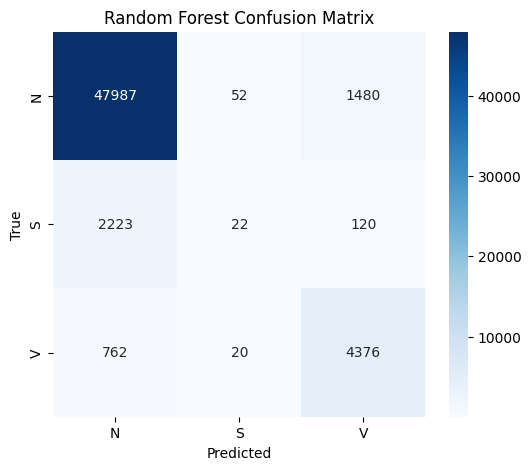


MODEL: Logistic Regression

Accuracy: 0.8355

Classification Report:
              precision    recall  f1-score   support

           N       0.93      0.89      0.91     49519
           S       0.06      0.09      0.07      2365
           V       0.55      0.69      0.61      5158

    accuracy                           0.84     57042
   macro avg       0.51      0.56      0.53     57042
weighted avg       0.86      0.84      0.85     57042



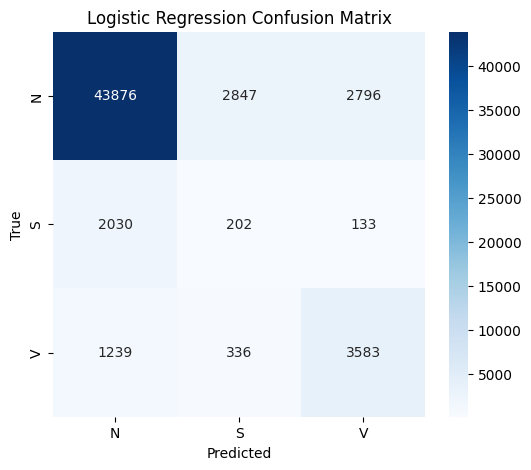


MODEL: Small Neural Network


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(



Accuracy: 0.7956

Classification Report:
              precision    recall  f1-score   support

           N       0.95      0.83      0.88     49519
           S       0.03      0.08      0.04      2365
           V       0.62      0.84      0.71      5158

    accuracy                           0.80     57042
   macro avg       0.53      0.58      0.54     57042
weighted avg       0.88      0.80      0.83     57042



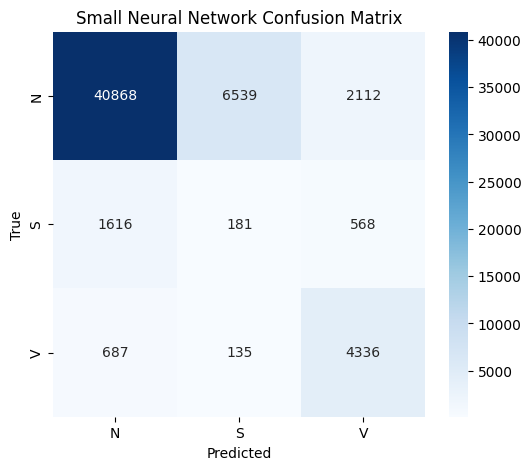


MODEL: Linear SVM

Accuracy: 0.8514

Classification Report:
              precision    recall  f1-score   support

           N       0.93      0.90      0.92     49519
           S       0.07      0.08      0.07      2365
           V       0.58      0.71      0.64      5158

    accuracy                           0.85     57042
   macro avg       0.53      0.56      0.54     57042
weighted avg       0.86      0.85      0.86     57042



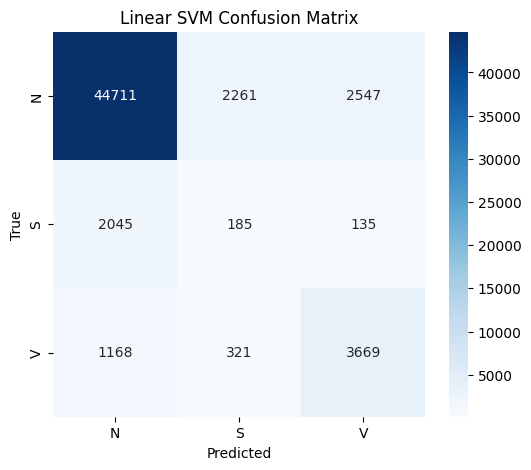


MODEL: KNN

Accuracy: 0.8210

Classification Report:
              precision    recall  f1-score   support

           N       0.96      0.84      0.90     49519
           S       0.11      0.27      0.16      2365
           V       0.57      0.87      0.69      5158

    accuracy                           0.82     57042
   macro avg       0.55      0.66      0.58     57042
weighted avg       0.89      0.82      0.85     57042



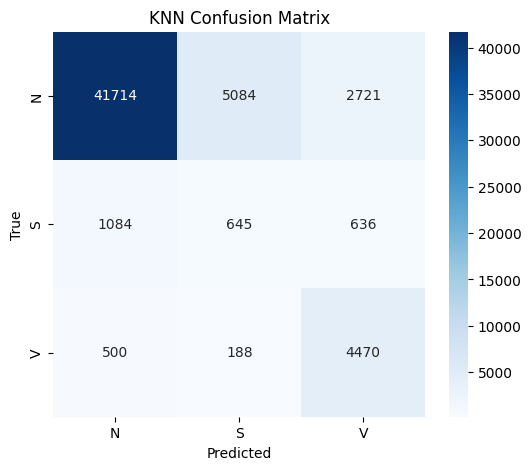


MODEL: Decision Tree

Accuracy: 0.8012

Classification Report:
              precision    recall  f1-score   support

           N       0.94      0.83      0.88     49519
           S       0.05      0.08      0.06      2365
           V       0.46      0.83      0.59      5158

    accuracy                           0.80     57042
   macro avg       0.48      0.58      0.51     57042
weighted avg       0.86      0.80      0.82     57042



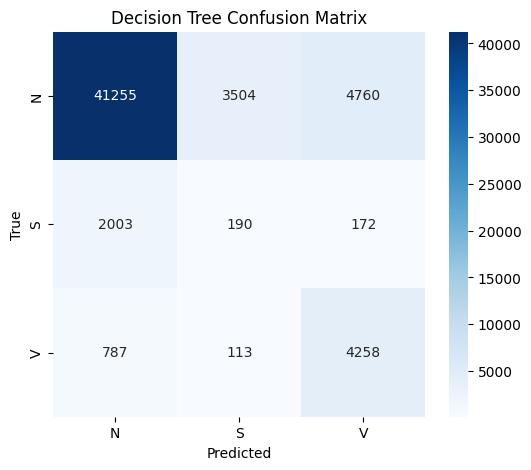

In [ ]:
results = {}

for name, model in models.items():

    print("\n===================================")
    print(f"MODEL: {name}")
    print("===================================")

    # Train
    model.fit(
        X_train_balanced,
        y_train_balanced
    )

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(
        y_test_enc,
        y_pred
    )

    print(f"\nAccuracy: {accuracy:.4f}")

    # Classification report
    report = classification_report(
        y_test_enc,
        y_pred,
        target_names=le.classes_
    )

    print("\nClassification Report:")
    print(report)

    # Save results
    results[name] = {
        "accuracy": accuracy,
        "report": report
    }

    # =========================
    # Confusion Matrix
    # =========================

    cm = confusion_matrix(
        y_test_enc,
        y_pred
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )

    plt.title(f"{name} Confusion Matrix")

    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()

Summary table

In [ ]:
print("\n========================")
print("FINAL ACCURACY SUMMARY")
print("========================")

for model_name, metrics in results.items():

    print(
        f"{model_name}: "
        f"{metrics['accuracy']:.4f}"
    )


FINAL ACCURACY SUMMARY
Random Forest: 0.9184
Logistic Regression: 0.8355
Small Neural Network: 0.7956
Linear SVM: 0.8514
KNN: 0.8210
Decision Tree: 0.8012


CNN Architecture

Import Libraries

In [ ]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

Reshape data

In [ ]:
print("Original Shapes:")
print(X_train_balanced.shape)
print(X_test.shape)

# CNN expects:
# (samples, timesteps, channels)

X_train_cnn = X_train_balanced.reshape(
    X_train_balanced.shape[0],
    X_train_balanced.shape[1],
    1
)

X_test_cnn = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("\nCNN Shapes:")
print(X_train_cnn.shape)
print(X_test_cnn.shape)

Original Shapes:
(117048, 147)
(57042, 147)

CNN Shapes:
(117048, 147, 1)
(57042, 147, 1)


Encode labels

In [ ]:
y_train_cat = to_categorical(y_train_balanced, num_classes=3)

y_test_cat = to_categorical(y_test_enc, num_classes=3)


Build CNN model

In [ ]:
cnn_model = Sequential([

    # ------------------------
    # Conv Block 1
    # ------------------------

    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(X_train_cnn.shape[1], 1)
    ),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    # ------------------------
    # Conv Block 2
    # ------------------------

    Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    # ------------------------
    # Flatten
    # ------------------------

    Flatten(),

    # ------------------------
    # Dense Layer
    # ------------------------

    Dense(
        64,
        activation='relu'
    ),

    Dropout(0.3),

    # ------------------------
    # Output Layer
    # ------------------------

    Dense(
        3,
        activation='softmax'
    )
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile model & Model summary

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 143, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 143, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 71, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 67, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 67, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 33, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2112)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       135,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 146,307 (571.51 KB)

 Trainable params: 146,115 (570.76 KB)

 Non-trainable params: 192 (768.00 B)

Train model

In [ ]:
history = cnn_model.fit(
    X_train_cnn,
    y_train_cat,

    epochs=10,
    batch_size=128,

    validation_split=0.1,

    verbose=1
)


Epoch 1/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9796 - loss: 0.0635 - val_accuracy: 0.9948 - val_loss: 0.0144
Epoch 2/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.9945 - loss: 0.0189 - val_accuracy: 0.9997 - val_loss: 0.0018
Epoch 3/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.9963 - loss: 0.0133 - val_accuracy: 0.9982 - val_loss: 0.0066
Epoch 4/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.9968 - loss: 0.0106 - val_accuracy: 0.9913 - val_loss: 0.0264
Epoch 5/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.9969 - loss: 0.0106 - val_accuracy: 0.9991 - val_loss: 0.0035
Epoch 6/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 42s 52ms/step - accuracy: 0.9973 - loss: 0.0096 - val_accuracy: 0.9992 - val_loss: 0.0028
Epoch 7/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.9981 - loss: 0.0064 - val_accuracy: 1.0000 - val_loss: 2.1320e-04
Epoch 8/10
823/823 ━━━━━━━━━━━━━━━━━━━━ 83s 52ms/step - accuracy: 0.9981 - loss: 0.006

Evaluate model

In [ ]:
loss, accuracy = cnn_model.evaluate(
    X_test_cnn,
    y_test_cat,
    verbose=0
)

print("\n===================================")
print("CNN RESULTS")
print("===================================")

print(f"\nAccuracy: {accuracy:.4f}")


CNN RESULTS

Accuracy: 0.8709


Predictions

In [ ]:

y_pred_prob = cnn_model.predict(X_test_cnn)

y_pred = np.argmax(y_pred_prob, axis=1)


1783/1783 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step


Classification report

In [ ]:

report = classification_report(
    y_test_enc,
    y_pred,
    target_names=le.classes_
)

print("\nClassification Report:")
print(report)



Classification Report:
              precision    recall  f1-score   support

           N       0.97      0.90      0.93     49519
           S       0.19      0.23      0.21      2365
           V       0.57      0.89      0.69      5158

    accuracy                           0.87     57042
   macro avg       0.57      0.67      0.61     57042
weighted avg       0.90      0.87      0.88     57042



Confusion matrix

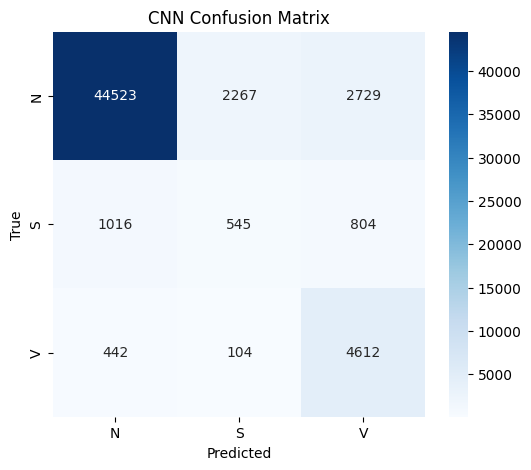

In [ ]:
cm = confusion_matrix(
    y_test_enc,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("CNN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()


Training curves

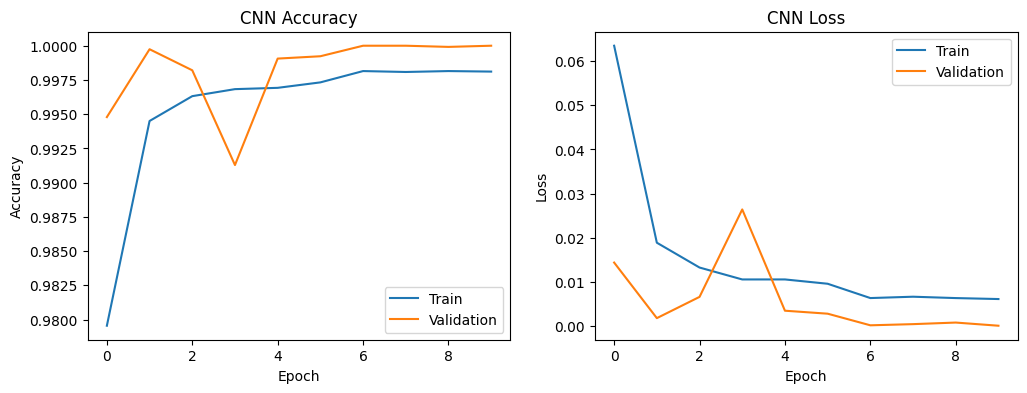

In [ ]:
plt.figure(figsize=(12,4))

# Accuracy

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("CNN Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

# Loss

plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("CNN Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()